# Benchmark: OCaml vs Animated Meta-Interpreter test times

Compares per-test wall-clock time between the two Wasm spec-test backends:

- **ocaml** — generated OCaml interpreter (`bench-ocmal-0702.log`)
- **anim** — animated meta-interpreter (`bench-anim-0702.log`)

Source data: `bench_times-0702.csv`. Tests with 0 assertions (e.g. `obsolete-keywords.wast`,
`binary-gc.wast`, the `utf8-*` parse-error tests) are excluded since they carry no
meaningful runtime signal.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Reference palette (dataviz skill default): fixed categorical slots, never cycled.
COLOR_OCAML = "#2a78d6"   # categorical slot 1 (blue)
COLOR_ANIM  = "#1baf7a"   # categorical slot 2 (aqua)
COLOR_MUTED = "#8a8a86"   # muted text/gridline ink
COLOR_GRID  = "#e3e2dd"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": COLOR_MUTED,
    "axes.grid": True,
    "grid.color": COLOR_GRID,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

In [15]:
df = pd.read_csv("bench_times-0702.csv")

# Drop tests with no assertions at all -- no runtime signal to compare.
df = df[(df["ocaml_total"] > 0) & (df["anim_total"] > 0)].reset_index(drop=True)

# Short, still-unique label (drop the common path prefix).
prefix = "test-interpreter/spec-test-3/"
df["label"] = df["test"].str.replace(prefix, "", regex=False)

df["speedup"] = df["anim_time_s"] / df["ocaml_time_s"]

print(f"{len(df)} tests after excluding empty ones")
# df.head()
df

185 tests after excluding empty ones


,test,ocaml_time_s,anim_time_s,ocaml_passed,ocaml_total,anim_passed,anim_total,label,speedup
0,test-interpreter/spec-test-3/address.wast,0.11495,2.47564,264,264,264,264,address.wast,21.536668
1,test-interpreter/spec-test-3/align.wast,0.03228,2.84019,142,142,142,142,align.wast,87.986059
2,test-interpreter/spec-test-3/annotations.wast,0.00379,0.12615,20,20,20,20,annotations.wast,33.284960
3,test-interpreter/spec-test-3/binary-leb128.wast,0.01590,0.20698,66,66,66,66,binary-leb128.wast,13.017610
4,test-interpreter/spec-test-3/binary.wast,0.00119,0.08312,40,40,40,40,binary.wast,69.848739
...,...,...,...,...,...,...,...,...,...
180,test-interpreter/spec-test-3/type.wast,0.00045,0.06362,2,2,2,2,type.wast,141.377778
181,test-interpreter/spec-test-3/unreachable.wast,0.00691,0.85468,65,65,65,65,unreachable.wast,123.687410
182,test-interpreter/spec-test-3/unreached-invalid...,0.00035,0.59667,121,121,121,121,unreached-invalid.wast,1704.771429
183,test-interpreter/spec-test-3/unreached-valid.wast,0.00131,0.22925,16,16,16,16,unreached-valid.wast,175.000000


## All tests: OCaml time vs animated time (log-log)

Each point is one test file. The dashed line is *y = x* (equal time in both
backends); everything above it is a test where the animated interpreter is
slower, which given the constant-factor overhead of animation is effectively
all of them here.

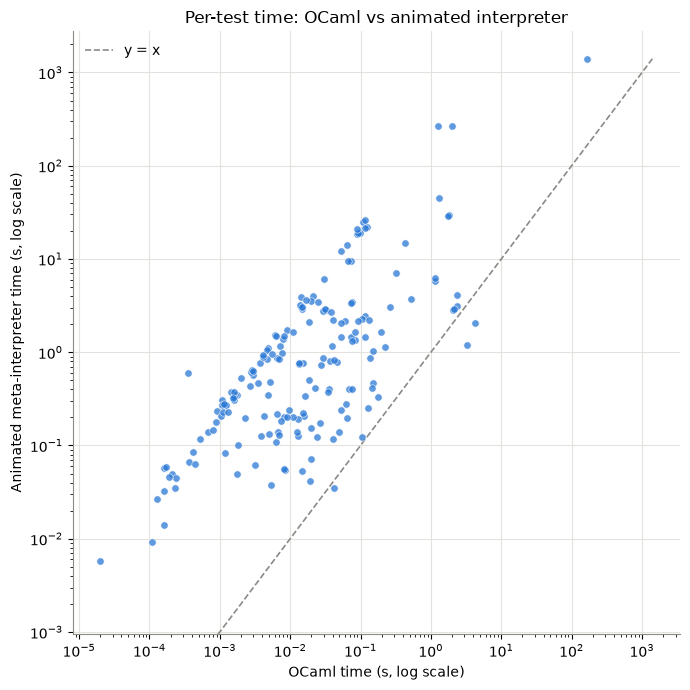

In [10]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(df["ocaml_time_s"], df["anim_time_s"], s=28,
           color=COLOR_OCAML, alpha=0.75, edgecolor="white", linewidth=0.5,
           zorder=3)

lo = min(df["ocaml_time_s"].min(), df["anim_time_s"].min(), 1e-4)
hi = max(df["ocaml_time_s"].max(), df["anim_time_s"].max())
ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.2, color=COLOR_MUTED, zorder=2, label="y = x")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("OCaml time (s, log scale)")
ax.set_ylabel("Animated meta-interpreter time (s, log scale)")
ax.set_title("Per-test time: OCaml vs animated interpreter")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

## Slowest tests (by animated time)

Top 25 tests ranked by animated-interpreter time, with the matching OCaml time
alongside for reference. Two series -> both are direct-labeled via the legend,
colors follow the entity (OCaml is always blue, animated is always aqua).

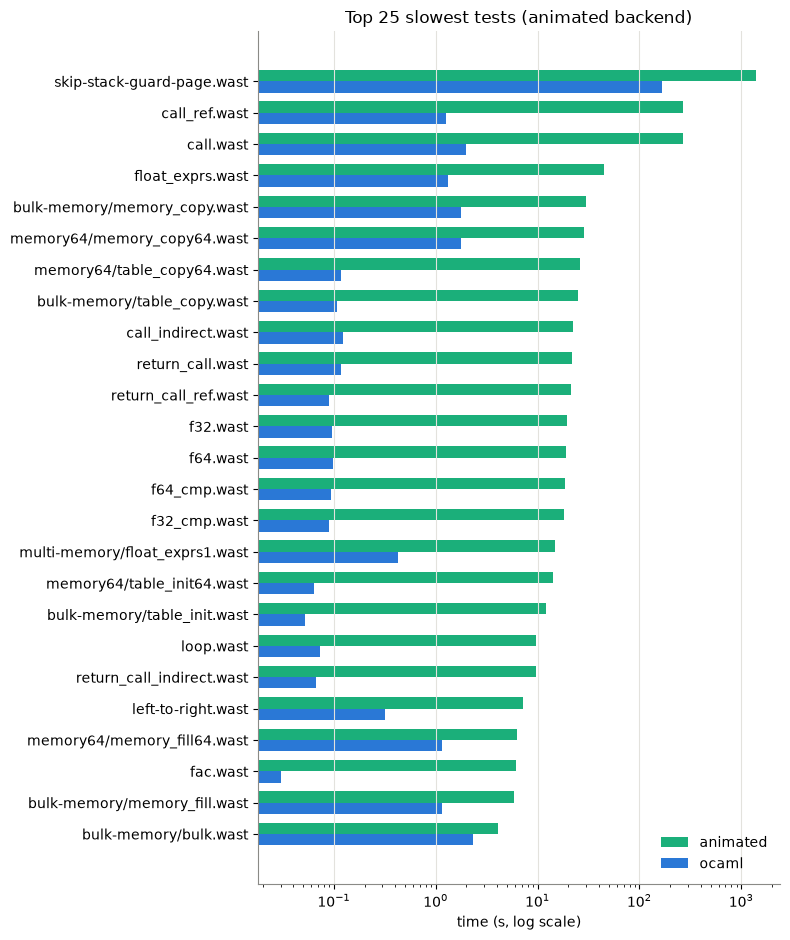

In [11]:
top_n = 25
top = df.nlargest(top_n, "anim_time_s").sort_values("anim_time_s")

y = np.arange(len(top))
h = 0.36

fig, ax = plt.subplots(figsize=(8, 0.32 * len(top) + 1.5))
ax.barh(y + h/2, top["anim_time_s"], height=h, color=COLOR_ANIM, label="animated")
ax.barh(y - h/2, top["ocaml_time_s"], height=h, color=COLOR_OCAML, label="ocaml")

ax.set_yticks(y)
ax.set_yticklabels(top["label"])
ax.set_xscale("log")
ax.set_xlabel("time (s, log scale)")
ax.set_title(f"Top {top_n} slowest tests (animated backend)")
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

## Slowdown factor (animated / OCaml)

Single series, one hue: how many times slower the animated interpreter is per
test, for the 25 tests with the largest slowdown factor.

/home/zilinc/miniconda3/envs/spectec-bench/lib/python3.13/site-packages/matplotlib/transforms.py:2496: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


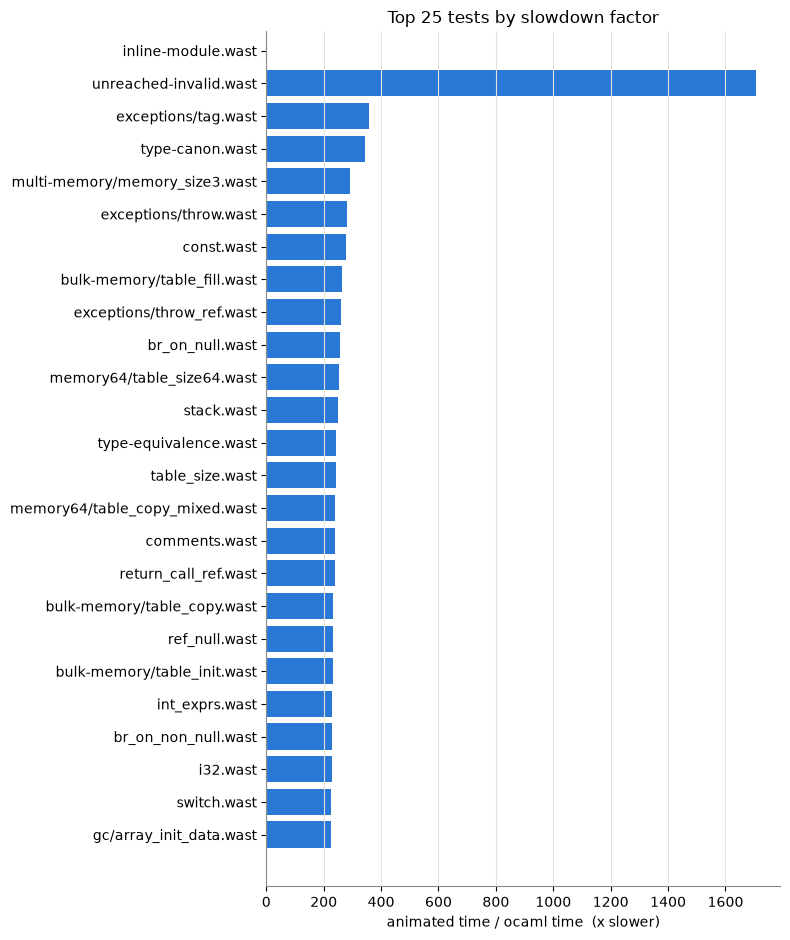

In [12]:
top_n = 25
top_speedup = df.nlargest(top_n, "speedup").sort_values("speedup")

fig, ax = plt.subplots(figsize=(8, 0.32 * len(top_speedup) + 1.5))
ax.barh(top_speedup["label"], top_speedup["speedup"], color=COLOR_OCAML)

ax.set_xlabel("animated time / ocaml time  (x slower)")
ax.set_title(f"Top {top_n} tests by slowdown factor")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

## Distribution of slowdown factors

How the animated/OCaml time ratio (`speedup` column) is distributed across all
included tests. Log-x scale since the ratio spans roughly 0.4x to >1000x. One
test (`inline-module.wast`) rounds to `0.00000s` for its OCaml time and is
excluded from this chart since it produces an infinite ratio.

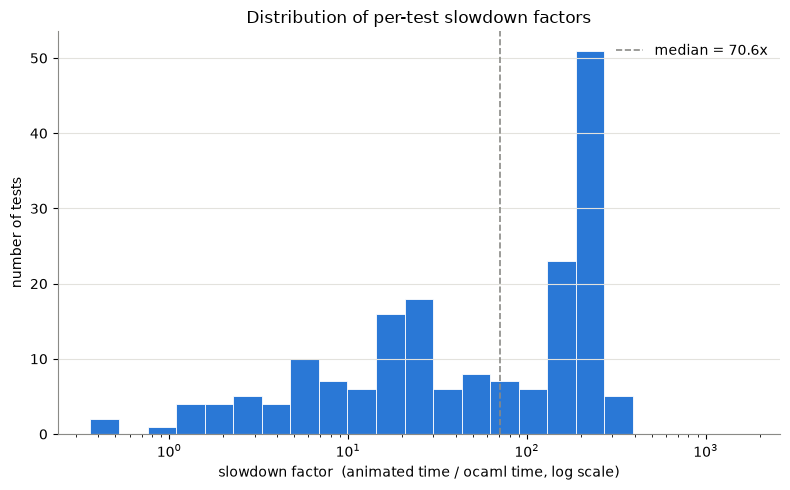

1 test(s) excluded from this chart (infinite ratio, ocaml_time_s rounds to 0.00000): inline-module.wast


In [16]:
finite = df[np.isfinite(df["speedup"])].copy()
n_dropped = len(df) - len(finite)

bins = np.logspace(np.log10(finite["speedup"].min()), np.log10(finite["speedup"].max()), 24)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(finite["speedup"], bins=bins, color=COLOR_OCAML, edgecolor="white", linewidth=0.6)

median = finite["speedup"].median()
ax.axvline(median, color=COLOR_MUTED, linestyle="--", linewidth=1.2, label=f"median = {median:.1f}x")

ax.set_xscale("log")
ax.set_xlabel("slowdown factor  (animated time / ocaml time, log scale)")
ax.set_ylabel("number of tests")
ax.set_title("Distribution of per-test slowdown factors")
ax.legend(frameon=False)
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

if n_dropped:
    print(f"{n_dropped} test(s) excluded from this chart (infinite ratio, ocaml_time_s rounds to 0.00000): "
          + ", ".join(df.loc[~np.isfinite(df['speedup']), 'label']))

## All tests, sorted by animated time

Full breakdown for reference / export. Tall figure by design -- one row per test.

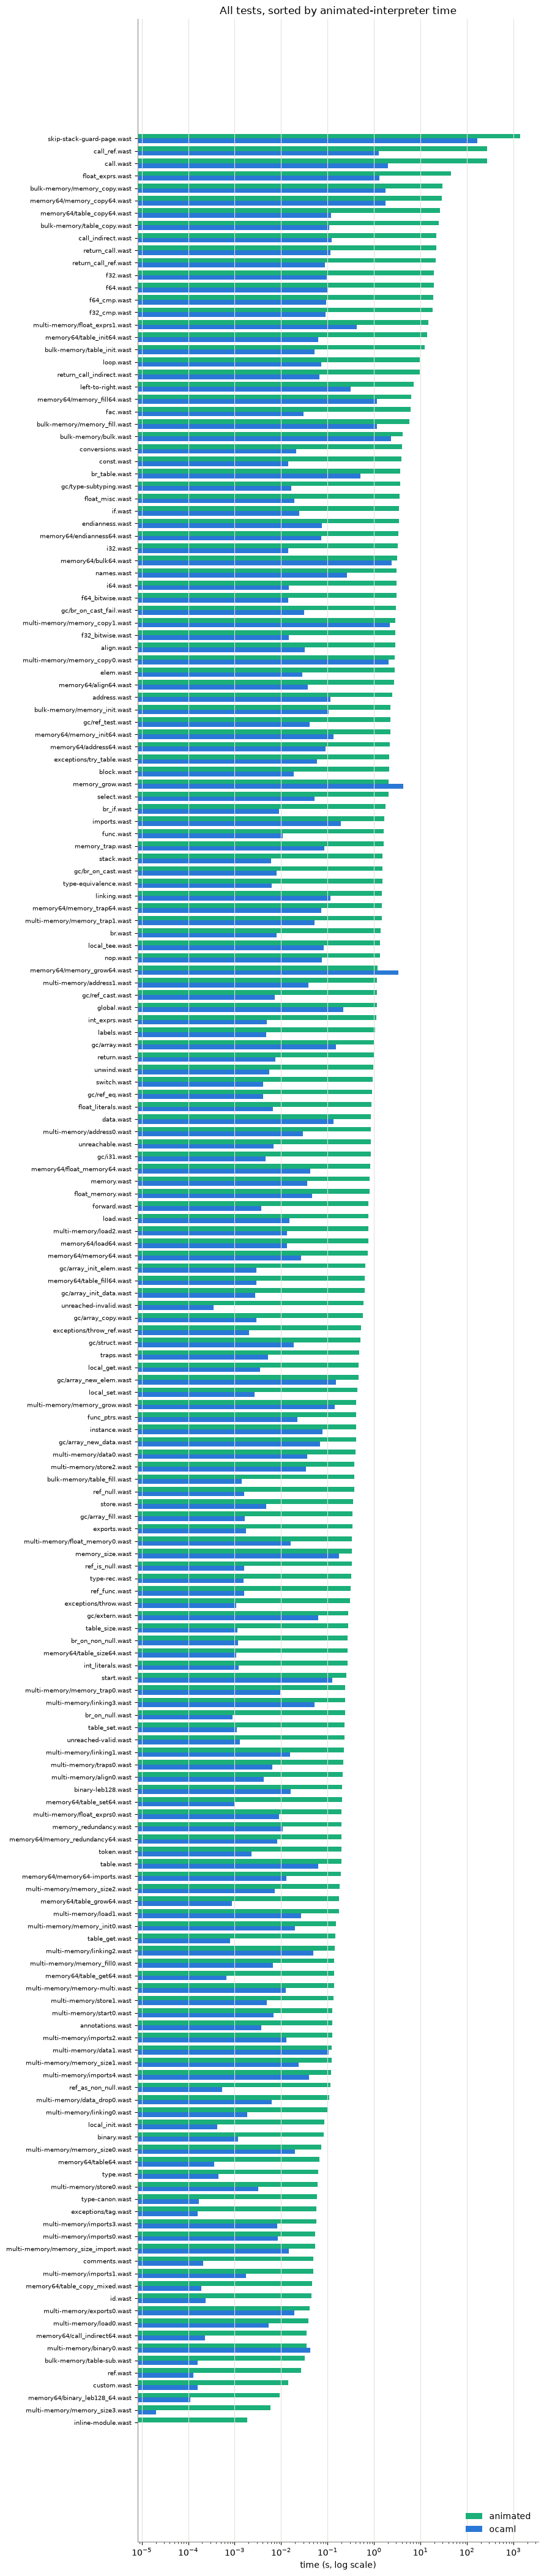

In [13]:
full = df.sort_values("anim_time_s")
y = np.arange(len(full))
h = 0.38

fig, ax = plt.subplots(figsize=(9, 0.22 * len(full) + 1.5))
ax.barh(y + h/2, full["anim_time_s"], height=h, color=COLOR_ANIM, label="animated")
ax.barh(y - h/2, full["ocaml_time_s"], height=h, color=COLOR_OCAML, label="ocaml")

ax.set_yticks(y)
ax.set_yticklabels(full["label"], fontsize=7)
ax.set_xscale("log")
ax.set_xlabel("time (s, log scale)")
ax.set_title("All tests, sorted by animated-interpreter time")
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

## Summary

In [14]:
summary = pd.DataFrame({
    "total_time_s": [df["ocaml_time_s"].sum(), df["anim_time_s"].sum()],
    "mean_time_s":  [df["ocaml_time_s"].mean(), df["anim_time_s"].mean()],
    "median_time_s":[df["ocaml_time_s"].median(), df["anim_time_s"].median()],
}, index=["ocaml", "animated"])
summary["overall_slowdown_x"] = summary["total_time_s"] / summary.loc["ocaml", "total_time_s"]
summary

,total_time_s,mean_time_s,median_time_s,overall_slowdown_x
ocaml,198.81459,1.074673,0.01461,1.000000
animated,2473.50774,13.370312,0.63638,12.441279
